<a href="https://colab.research.google.com/github/narwayvivek/genai-bronze-certification/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(90deg, #2c3e50 0%, #3498db 100%);
            padding: 25px; border-radius: 20px; text-align: center;
            color: white; font-family: 'Arial Black', sans-serif;
            box-shadow: 0 10px 40px rgba(0,0,0,0.4); margin: 20px 0;
            border: 3px solid #ecf0f1;">

**💼 VIVEK NARWAY**  
**🏢 SAP ID: 52217413**  


</div>

**Write a Python program to draw a 3D plot that visualizes the regression model for house price prediction using suitable Python-based 3D plotting libraries.**

**Assume the following features were used:**  
**Area (sq ft)**  
**Number of Bedrooms**  
**House Price**


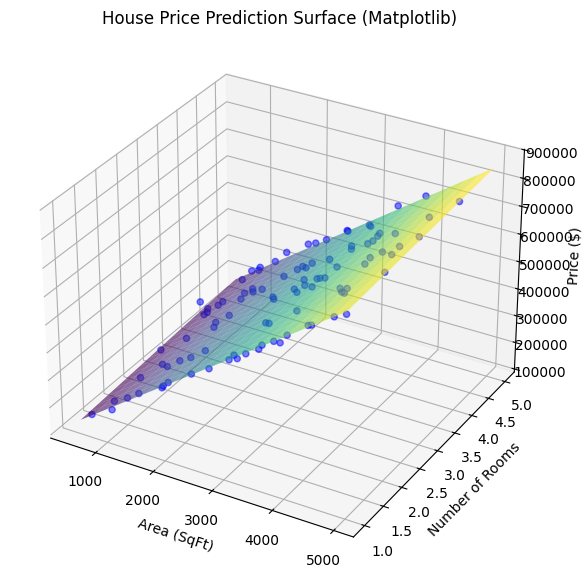

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# 1. Create Sample Data (Area, Bedrooms, and Price)
np.random.seed(42)
n_samples = 100
area = np.random.randint(500, 5000, n_samples)
rooms = np.random.randint(1, 6, n_samples)
# Price formula: 50,000 + (150 * area) + (10,000 * rooms) + noise
price = 50000 + (150 * area) + (10000 * rooms) + np.random.normal(0, 10000, n_samples)

# 2. Train a Simple Linear Regression Model
X = np.column_stack((area, rooms))
model = LinearRegression()
model.fit(X, price)

# 3. Create a Meshgrid for the 3D Surface
area_range = np.linspace(area.min(), area.max(), 20)
rooms_range = np.linspace(rooms.min(), rooms.max(), 20)
Area_grid, Rooms_grid = np.meshgrid(area_range, rooms_range)

# Predict prices over the grid to form the surface
Price_surface = model.predict(np.c_[Area_grid.ravel(), Rooms_grid.ravel()])
Price_surface = Price_surface.reshape(Area_grid.shape)

# --- PLOT 1: STATIC
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(area, rooms, price, color='blue', alpha=0.5, label='Actual Data')
surf = ax.plot_surface(Area_grid, Rooms_grid, Price_surface, cmap='viridis', alpha=0.6)
ax.set_xlabel('Area (SqFt)')
ax.set_ylabel('Number of Rooms')
ax.set_zlabel('Price ($)')
plt.title('House Price Prediction Surface (Matplotlib)')
plt.show()

# --- PLOT 2: INTERACTIVE
fig_interactive = go.Figure(data=[
    go.Scatter3d(x=area, y=rooms, z=price, mode='markers', marker=dict(size=4, color='blue', opacity=0.5), name='Actual Data'),
    go.Surface(x=area_range, y=rooms_range, z=Price_surface, colorscale='Viridis', opacity=0.7, name='Prediction Plane')
])
fig_interactive.update_layout(title='Interactive House Price Prediction Model',
                              scene=dict(xaxis_title='Area (SqFt)',
                                         yaxis_title='Rooms',
                                         zaxis_title='Price ($)'))
fig_interactive.show()